# 1. Business Problem
## RideWise is experiencing customer churn, where users stop booking trips after a period of inactivity.
### Objective: Define and identify churned customers
### Analyse customer behaviour and engagement patterns
### Segment customers based on usage behaviour
### Build a predictive model to identify customers at risk of churning
### Generate actionable business insights to support retention strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# 2. Data Loading

In [2]:
riders = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\riders.csv")
trips = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\trips.csv")
promotions = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\promotions.csv")
sessions = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\sessions.csv")
drivers = pd.read_csv(r"C:\Users\HP\Downloads\ridewise-churn\data\raw\drivers.csv")

print("riders:", riders.shape)
print("trips:", trips.shape)
print("promotions:", promotions.shape)
print("sessions:", sessions.shape)
print("drivers:", drivers.shape)

riders: (10000, 8)
trips: (200000, 16)
promotions: (20, 11)
sessions: (50000, 8)
drivers: (5000, 7)


# 3. Data Understanding (Info + Columns)

In [3]:
riders.head()

,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


In [4]:
riders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           10000 non-null  object 
 1   signup_date       10000 non-null  object 
 2   loyalty_status    10000 non-null  object 
 3   age               10000 non-null  float64
 4   city              10000 non-null  object 
 5   avg_rating_given  10000 non-null  float64
 6   churn_prob        10000 non-null  float64
 7   referred_by       3053 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


In [5]:
riders.columns

Index(['user_id', 'signup_date', 'loyalty_status', 'age', 'city',
       'avg_rating_given', 'churn_prob', 'referred_by'],
      dtype='object')

In [6]:
trips.head()

,trip_id,user_id,driver_id,fare,surge_multiplier,tip,payment_type,pickup_time,dropoff_time,pickup_lat,pickup_lng,dropoff_lat,dropoff_lng,weather,city,loyalty_status
0,T000000,R05207,D00315,12.11,1.0,0.00,Card,2024-11-27 18:41:50+02:27,2024-11-27 19:33:50+02:27,-1.108123,36.912209,-1.068155,36.875377,Foggy,Nairobi,Bronze
1,T000001,R09453,D03717,8.73,1.0,0.02,Card,2024-10-28 23:13:48+00:14,2024-10-28 23:26:48+00:14,6.675266,3.515740,6.641734,3.525620,Sunny,Lagos,Gold
2,T000002,R00567,D02035,19.68,1.0,0.00,Card,2025-02-17 05:36:41+02:27,2025-02-17 05:52:41+02:27,-1.248589,37.010668,-1.273182,37.018586,Cloudy,Nairobi,Bronze
3,T000003,R09573,D02657,16.43,1.0,0.01,Mobile Money,2024-06-18 19:27:14+02:05,2024-06-18 19:32:14+02:05,29.819554,31.188780,29.837689,31.232978,Cloudy,Cairo,Bronze
4,T000004,R03446,D01026,8.70,1.0,1.06,Card,2024-10-05 09:58:16+02:27,2024-10-05 10:28:16+02:27,-1.676479,36.729219,-1.638395,36.694063,Sunny,Nairobi,Gold


In [7]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   trip_id           200000 non-null  object 
 1   user_id           200000 non-null  object 
 2   driver_id         200000 non-null  object 
 3   fare              200000 non-null  float64
 4   surge_multiplier  200000 non-null  float64
 5   tip               200000 non-null  float64
 6   payment_type      200000 non-null  object 
 7   pickup_time       200000 non-null  object 
 8   dropoff_time      200000 non-null  object 
 9   pickup_lat        200000 non-null  float64
 10  pickup_lng        200000 non-null  float64
 11  dropoff_lat       200000 non-null  float64
 12  dropoff_lng       200000 non-null  float64
 13  weather           200000 non-null  object 
 14  city              200000 non-null  object 
 15  loyalty_status    200000 non-null  object 
dtypes: float64(7), objec

In [8]:
trips.columns

Index(['trip_id', 'user_id', 'driver_id', 'fare', 'surge_multiplier', 'tip',
       'payment_type', 'pickup_time', 'dropoff_time', 'pickup_lat',
       'pickup_lng', 'dropoff_lat', 'dropoff_lng', 'weather', 'city',
       'loyalty_status'],
      dtype='object')

In [9]:
promotions.head()

,promo_id,promo_name,promo_type,promo_value,start_date,end_date,target_segment,city_scope,ab_test_groups,test_allocation,success_metric
0,P000,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-25,All,Nairobi,['All'],[1.0],Usage Frequency
1,P001,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-22,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
2,P002,Peak Hour Pass,surge_waiver,1.0,2025-04-26,2025-05-16,All,Cairo,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",ROI
3,P003,Loyalty Bonus,points,100.0,2025-04-26,2025-05-04,Gold+,Nairobi,"['Control', 'Variant A', 'Variant B']","[0.3, 0.4, 0.3]",Conversion Rate
4,P004,Loyalty Bonus,points,100.0,2025-04-26,2025-05-15,Gold+,Nairobi,['All'],[1.0],Usage Frequency


In [10]:
promotions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   promo_id         20 non-null     object 
 1   promo_name       20 non-null     object 
 2   promo_type       20 non-null     object 
 3   promo_value      20 non-null     float64
 4   start_date       20 non-null     object 
 5   end_date         20 non-null     object 
 6   target_segment   20 non-null     object 
 7   city_scope       20 non-null     object 
 8   ab_test_groups   20 non-null     object 
 9   test_allocation  20 non-null     object 
 10  success_metric   20 non-null     object 
dtypes: float64(1), object(10)
memory usage: 1.8+ KB


In [11]:
promotions.columns

Index(['promo_id', 'promo_name', 'promo_type', 'promo_value', 'start_date',
       'end_date', 'target_segment', 'city_scope', 'ab_test_groups',
       'test_allocation', 'success_metric'],
      dtype='object')

In [12]:
sessions.head()

,session_id,rider_id,session_time,time_on_app,pages_visited,converted,city,loyalty_status
0,S000000,R08605,2025-04-27 18:57:06+02:05,79,4,1,Cairo,Bronze
1,S000001,R08823,2025-04-27 07:32:22+02:27,101,3,0,Nairobi,Silver
2,S000002,R05342,2025-04-27 23:17:25+02:05,12,1,0,Cairo,Bronze
3,S000003,R05057,2025-04-27 14:40:25+00:14,19,1,0,Lagos,Silver
4,S000004,R09614,2025-04-27 08:31:22+00:14,4,1,0,Lagos,Bronze


In [13]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   session_id      50000 non-null  object
 1   rider_id        50000 non-null  object
 2   session_time    50000 non-null  object
 3   time_on_app     50000 non-null  int64 
 4   pages_visited   50000 non-null  int64 
 5   converted       50000 non-null  int64 
 6   city            50000 non-null  object
 7   loyalty_status  50000 non-null  object
dtypes: int64(3), object(5)
memory usage: 3.1+ MB


In [14]:
sessions.columns

Index(['session_id', 'rider_id', 'session_time', 'time_on_app',
       'pages_visited', 'converted', 'city', 'loyalty_status'],
      dtype='object')

In [15]:
drivers.head()

,driver_id,rating,vehicle_type,signup_date,last_active,city,acceptance_rate
0,D00000,3.1,SUV,1/20/2025,23:09.3,Cairo,0.679555
1,D00001,5.0,Sedan,3/27/2023,44:02.5,Nairobi,0.548786
2,D00002,4.5,Motorcycle,5/2/2024,24:46.4,Nairobi,0.593724
3,D00003,5.0,Motorcycle,4/16/2023,16:24.3,Nairobi,0.990000
4,D00004,4.4,Motorcycle,5/28/2023,54:44.6,Lagos,0.519773


In [16]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   driver_id        5000 non-null   object 
 1   rating           5000 non-null   float64
 2   vehicle_type     5000 non-null   object 
 3   signup_date      5000 non-null   object 
 4   last_active      5000 non-null   object 
 5   city             5000 non-null   object 
 6   acceptance_rate  5000 non-null   float64
dtypes: float64(2), object(5)
memory usage: 273.6+ KB


In [17]:
drivers.columns

Index(['driver_id', 'rating', 'vehicle_type', 'signup_date', 'last_active',
       'city', 'acceptance_rate'],
      dtype='object')

# 4. Data Cleaning & Datetime Parsing

In [18]:
sessions = sessions.rename(columns={'rider_id': 'user_id'})

In [19]:
sessions.columns

Index(['session_id', 'user_id', 'session_time', 'time_on_app', 'pages_visited',
       'converted', 'city', 'loyalty_status'],
      dtype='object')

In [20]:
riders['signup_date'] = pd.to_datetime(riders['signup_date'])

In [21]:
# trips['pickup_time'] = pd.to_datetime(trips['pickup_time'])

In [22]:
sessions['session_time'] = pd.to_datetime(sessions['session_time'])

C:\Users\HP\AppData\Local\Temp\ipykernel_18392\1036228153.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  sessions['session_time'] = pd.to_datetime(sessions['session_time'])


In [23]:
trips['pickup_time'].min(), trips['pickup_time'].max()

('2024-04-27 00:07:34+02:27', '2025-04-27 23:57:26+00:14')

In [24]:
sessions['session_time'].min(), sessions['session_time'].max()

(Timestamp('2025-04-27 00:00:06+0227', tz='UTC+02:27'),
 Timestamp('2025-04-27 23:59:59+0014', tz='UTC+00:14'))

# 5. Churn Definition (30-day inactivity)

In [25]:
reference_date = trips['pickup_time'].max()
reference_date

'2025-04-27 23:57:26+00:14'

In [26]:
# Convert to datetime first
trips['pickup_time'] = pd.to_datetime(trips['pickup_time'], errors='coerce', utc=True)

# Remove timezone (make it timezone-naive) so subtraction works everywhere
trips['pickup_time'] = trips['pickup_time'].dt.tz_localize(None)

print(trips['pickup_time'].dtype)
trips['pickup_time'].head()

datetime64[ns]


0   2024-11-27 16:14:50
1   2024-10-28 22:59:48
2   2025-02-17 03:09:41
3   2024-06-18 17:22:14
4   2024-10-05 07:31:16
Name: pickup_time, dtype: datetime64[ns]

In [27]:
reference_date = trips['pickup_time'].max()

last_trip = trips.groupby('user_id')['pickup_time'].max().reset_index()

last_trip['days_since_last_trip'] = (reference_date - last_trip['pickup_time']).dt.days

last_trip['churn'] = (last_trip['days_since_last_trip'] > 30).astype(int)

last_trip[['user_id','days_since_last_trip','churn']].head()

,user_id,days_since_last_trip,churn
0,R00000,25,0
1,R00001,5,0
2,R00002,14,0
3,R00003,61,1
4,R00004,12,0


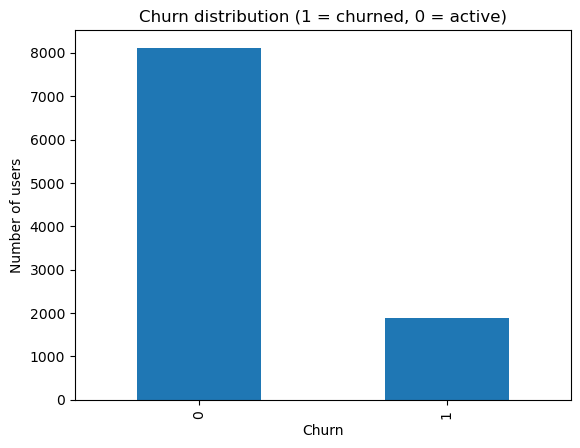

In [28]:
import matplotlib.pyplot as plt

plt.figure()
last_trip['churn'].value_counts().plot(kind='bar')
plt.title("Churn distribution (1 = churned, 0 = active)")
plt.xlabel("Churn")
plt.ylabel("Number of users")
plt.show()

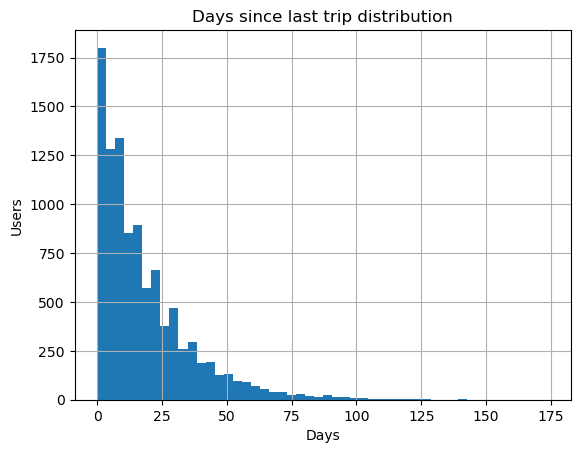

In [29]:
plt.figure()
last_trip['days_since_last_trip'].hist(bins=50)
plt.title("Days since last trip distribution")
plt.xlabel("Days")
plt.ylabel("Users")
plt.show()

In [30]:
# Sanity checks (safe)
print("pickup_time dtype:", trips['pickup_time'].dtype)
print("pickup_time missing:", trips['pickup_time'].isna().sum())
print("pickup_time range:", trips['pickup_time'].min(), "→", trips['pickup_time'].max())

print("\nlast_trip columns:", last_trip.columns.tolist())
print("churn counts:\n", last_trip['churn'].value_counts())
print("\nlast_trip preview:")
last_trip[['user_id','pickup_time','days_since_last_trip','churn']].head()

pickup_time dtype: datetime64[ns]
pickup_time missing: 0
pickup_time range: 2024-04-26 21:40:34 → 2025-04-27 23:43:26

last_trip columns: ['user_id', 'pickup_time', 'days_since_last_trip', 'churn']
churn counts:
 churn
0    8114
1    1886
Name: count, dtype: int64

last_trip preview:


,user_id,pickup_time,days_since_last_trip,churn
0,R00000,2025-04-02 14:46:29,25,0
1,R00001,2025-04-22 04:35:17,5,0
2,R00002,2025-04-13 00:08:00,14,0
3,R00003,2025-02-25 04:22:32,61,1
4,R00004,2025-04-15 05:30:04,12,0


In [31]:
last_trip.columns

Index(['user_id', 'pickup_time', 'days_since_last_trip', 'churn'], dtype='object')

In [32]:
last_trip[['days_since_last_trip','churn']].head()

,days_since_last_trip,churn
0,25,0
1,5,0
2,14,0
3,61,1
4,12,0


In [35]:
import os
print(os.getcwd())

c:\Users\HP\OneDrive\Documents\GitHub\Ridewise_London\notebooks


In [36]:
import os

# Makes sure processed folder exists
os.makedirs("../data/processed", exist_ok=True)

# Save files
riders.to_csv("../data/processed/riders_clean.csv", index=False)
trips.to_csv("../data/processed/trips_clean.csv", index=False)
sessions.to_csv("../data/processed/sessions_clean.csv", index=False)
promotions.to_csv("../data/processed/promotions_clean.csv", index=False)
last_trip.to_csv("../data/processed/churn_base.csv", index=False)

print("Files saved successfully.")

Files saved successfully.
